Chargement des données depuis prices_round_0_day_-1.csv...


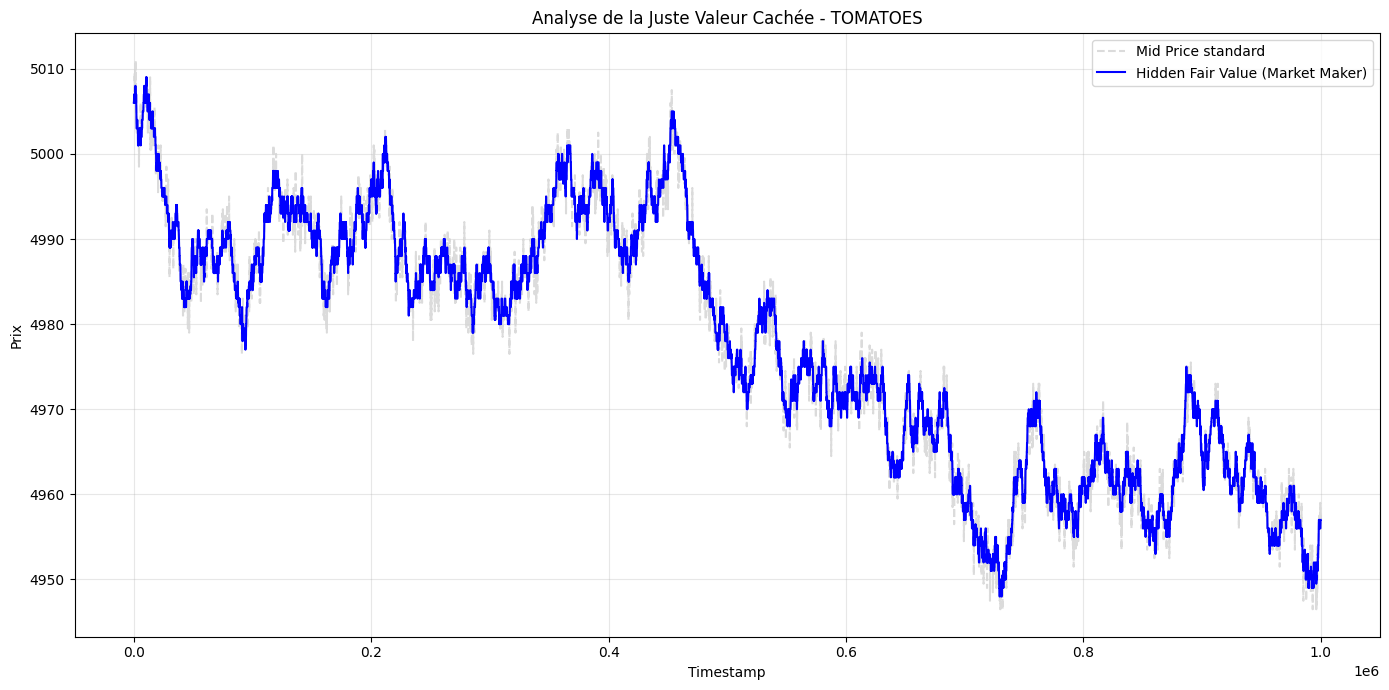

Chargement des données depuis prices_round_0_day_-2.csv...


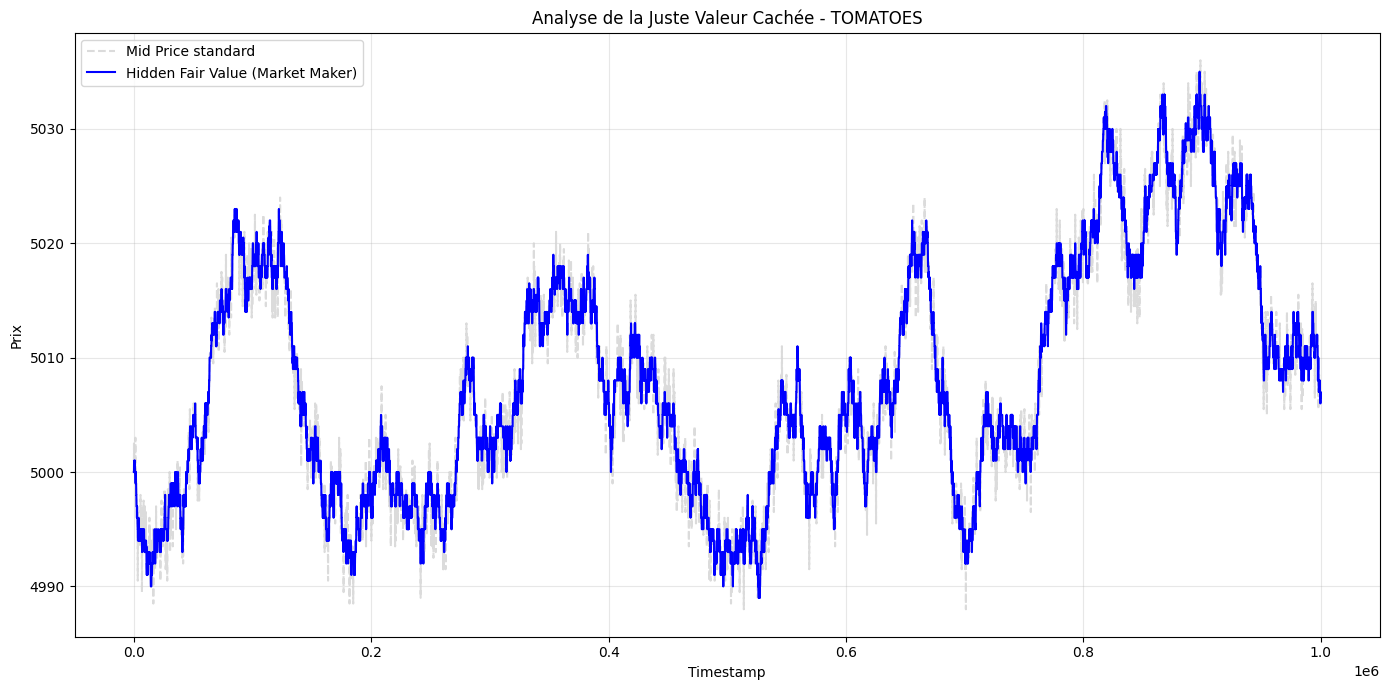

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_hidden_fair_value(csv_path, product="TOMATOES", vol_threshold=15, sym_tolerance=3):
    # 1. Chargement des données
    print(f"Chargement des données depuis {csv_path}...")
    df = pd.read_csv(csv_path, sep=';')
    
    # Isoler le produit cible
    df = df[df['product'] == product].copy()
    df.sort_values('timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Remplacer les valeurs NaN par 0 pour les niveaux du carnet vides
    vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 
                'ask_volume_1', 'ask_volume_2', 'ask_volume_3']
    df[vol_cols] = df[vol_cols].fillna(0)

    hidden_fvs = []
    
    # 2. Extraction ligne par ligne (Simulation du tick par tick)
    for index, row in df.iterrows():
        # Reconstruire les niveaux du carnet pour ce tick
        bids = {
            row['bid_price_1']: row['bid_volume_1'],
            row['bid_price_2']: row['bid_volume_2'],
            row['bid_price_3']: row['bid_volume_3']
        }
        asks = {
            row['ask_price_1']: abs(row['ask_volume_1']), # abs() par sécurité
            row['ask_price_2']: abs(row['ask_volume_2']),
            row['ask_price_3']: abs(row['ask_volume_3'])
        }
        
        # Nettoyer les niveaux vides (prix NaN ou volume 0)
        bids = {p: v for p, v in bids.items() if pd.notna(p) and v > 0}
        asks = {p: v for p, v in asks.items() if pd.notna(p) and v > 0}
        
        current_fv = np.nan
        
        if bids and asks:
            # Trouver le prix associé au volume maximum
            best_bid_price = max(bids.keys(), key=lambda p: bids[p])
            max_bid_vol = bids[best_bid_price]
            
            best_ask_price = max(asks.keys(), key=lambda p: asks[p])
            max_ask_vol = asks[best_ask_price]
            
            # Application des filtres de détection du Market Maker
            if max_bid_vol >= vol_threshold and max_ask_vol >= vol_threshold:
                if abs(max_bid_vol - max_ask_vol) <= sym_tolerance:
                    current_fv = (best_bid_price + best_ask_price) / 2.0
                    
        hidden_fvs.append(current_fv)
        
    # 3. Intégration et gestion du fallback
    df['hidden_fv'] = hidden_fvs
    
    # Fallback : on remplit les "trous" (quand le bot est absent) avec la dernière valeur connue
    df['hidden_fv'] = df['hidden_fv'].ffill()
    
    # S'il reste des NaN au tout début (avant la première apparition du bot), on utilise le mid_price classique
    df['hidden_fv'] = df['hidden_fv'].fillna(df['mid_price'])

    # 4. Visualisation
    plt.figure(figsize=(14, 7))
    plt.plot(df['timestamp'], df['mid_price'], label='Mid Price standard', color='lightgray', alpha=0.8, linestyle='--')
    plt.plot(df['timestamp'], df['hidden_fv'], label='Hidden Fair Value (Market Maker)', color='blue', linewidth=1.5)
    
    plt.title(f"Analyse de la Juste Valeur Cachée - {product}")
    plt.xlabel("Timestamp")
    plt.ylabel("Prix")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df

# --- UTILISATION ---
# Modifiez le chemin vers votre fichier CSV d'entraînement
# Par exemple : "TUTORIAL_ROUND_1/prices_round_0_day_-1.csv"
file_path = "prices_round_0_day_-1.csv" 

# Vous pouvez ajuster les seuils ici pour voir comment le signal réagit
df_analyzed = analyze_hidden_fair_value(
    csv_path="prices_round_0_day_-1.csv", 
    product="TOMATOES", 
    vol_threshold=10, 
    sym_tolerance=3
)

df_analyzed = analyze_hidden_fair_value(
    csv_path="prices_round_0_day_-2.csv", 
    product="TOMATOES", 
    vol_threshold=10, 
    sym_tolerance=3
)

In [8]:
#test des parametres de symetrie et de volatilité

import scipy.stats as stats
import time

def optimize_parameters(csv_path, product="TOMATOES", future_ticks=15):
    print(f"Chargement des données depuis {csv_path}...")
    df_brut = pd.read_csv(csv_path, sep=';')
    
    # Préparation des données (exécutée une seule fois)
    df = df_brut[df_brut['product'] == product].copy()
    df.sort_values('timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 
                'ask_volume_1', 'ask_volume_2', 'ask_volume_3']
    df[vol_cols] = df[vol_cols].fillna(0)
    
    # Les plages de paramètres à tester
    vol_thresholds = [10, 15, 20, 25, 30]
    sym_tolerances = [0, 1, 2, 3, 4, 5]
    
    results = []
    
    print("Début de la recherche sur grille (Grid Search)...")
    start_time = time.time()
    
    # Double boucle FOR pour tester toutes les combinaisons
    for v_thresh in vol_thresholds:
        for s_tol in sym_tolerances:
            hidden_fvs = []
            
            # Simulation tick par tick pour cette combinaison
            for index, row in df.iterrows():
                bids = {
                    row['bid_price_1']: row['bid_volume_1'],
                    row['bid_price_2']: row['bid_volume_2'],
                    row['bid_price_3']: row['bid_volume_3']
                }
                asks = {
                    row['ask_price_1']: abs(row['ask_volume_1']),
                    row['ask_price_2']: abs(row['ask_volume_2']),
                    row['ask_price_3']: abs(row['ask_volume_3'])
                }
                
                bids = {p: v for p, v in bids.items() if pd.notna(p) and v > 0}
                asks = {p: v for p, v in asks.items() if pd.notna(p) and v > 0}
                
                current_fv = np.nan
                
                if bids and asks:
                    best_bid_price = max(bids.keys(), key=lambda p: bids[p])
                    max_bid_vol = bids[best_bid_price]
                    
                    best_ask_price = max(asks.keys(), key=lambda p: asks[p])
                    max_ask_vol = asks[best_ask_price]
                    
                    # Application des paramètres de la boucle
                    if max_bid_vol >= v_thresh and max_ask_vol >= v_thresh:
                        if abs(max_bid_vol - max_ask_vol) <= s_tol:
                            current_fv = (best_bid_price + best_ask_price) / 2.0
                            
                hidden_fvs.append(current_fv)
                
            # Évaluation rapide pour cette combinaison
            eval_df = pd.DataFrame({
                'mid_price': df['mid_price'],
                'hidden_fv': hidden_fvs
            })
            
            eval_df['hidden_fv'] = eval_df['hidden_fv'].ffill().fillna(eval_df['mid_price'])
            
            # Calcul des métriques
            mid_volatility = eval_df['mid_price'].diff().abs().mean()
            fv_volatility = eval_df['hidden_fv'].diff().abs().mean()
            volatility_reduction = 1 - (fv_volatility / mid_volatility)
            
            eval_df['signal_fv'] = eval_df['hidden_fv'] - eval_df['mid_price']
            eval_df['future_return'] = eval_df['mid_price'].shift(-future_ticks) - eval_df['mid_price']
            
            # Nettoyage des NaN pour la corrélation
            clean_df = eval_df.dropna(subset=['signal_fv', 'future_return'])
            
            if len(clean_df) > 10: # S'assurer qu'on a assez de données
                correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
            else:
                correlation, p_value = 0, 1
                
            # Sauvegarde du résultat
            results.append({
                'Volume Threshold': v_thresh,
                'Symmetry Tolerance': s_tol,
                'Correlation': correlation,
                'P-Value': p_value,
                'Volatility Reduction': volatility_reduction
            })
            
    # Fin de la boucle, conversion en DataFrame pour affichage propre
    results_df = pd.DataFrame(results)
    
    # On trie par la meilleure corrélation
    results_df = results_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
    
    elapsed_time = time.time() - start_time
    print(f"Terminé en {elapsed_time:.2f} secondes.")
    print("\n=== TOP 5 DES MEILLEURES COMBINAISONS ===")
    print(results_df.head())
    
    return results_df

# --- UTILISATION ---
# N'oubliez pas d'ajuster le chemin vers votre CSV
file_path = "prices_round_0_day_-1.csv"
best_params_df = optimize_parameters(file_path, product="TOMATOES", future_ticks=15)


Chargement des données depuis prices_round_0_day_-1.csv...
Début de la recherche sur grille (Grid Search)...


/tmp/ipykernel_13431/346501518.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/346501518.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/346501518.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/346501518.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/346501518.py:85: ConstantInputWarning: An input array is constant; the correlation coeffici

Terminé en 17.50 secondes.

=== TOP 5 DES MEILLEURES COMBINAISONS ===
   Volume Threshold  Symmetry Tolerance  Correlation  P-Value  \
0                10                   0     0.376601      0.0   
1                10                   1     0.376601      0.0   
2                10                   2     0.376601      0.0   
3                10                   3     0.376601      0.0   
4                10                   4     0.376601      0.0   

   Volatility Reduction  
0               0.48594  
1               0.48594  
2               0.48594  
3               0.48594  
4               0.48594  


/tmp/ipykernel_13431/346501518.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])


In [52]:
from datamodel import OrderDepth, TradingState, Order
import json
import math

class Trader:
    def run(self, state: TradingState):
        result = {}
        conversions = 0
        
        # 1. MÉMOIRE
        try:
            memory = json.loads(state.traderData) if state.traderData else {}
        except Exception:
            memory = {}
            
        tomatoes_fv_history = memory.get("TOMATOES_FV", [])
        
                   # ---------------------------------------------------------
        # 3. STRATÉGIE TOMATOES : COMBINAISON ORACLE + MVA + FILTRE TENDANCE
        # ---------------------------------------------------------
        product_tom = "TOMATOES"
        
        # Récupération de la mémoire des prix
        tomatoes_prices = memory.get("TOMATOES_PRICES", [])
        
        if product_tom in state.order_depths:
            bids = state.order_depths[product_tom].buy_orders
            asks = state.order_depths[product_tom].sell_orders
            
            if bids and asks:
                # --- 1. CALCUL DE LA MVA ET TENDANCE ---
                best_bid_price = max(bids.keys())
                best_ask_price = min(asks.keys())
                current_mid = (best_bid_price + best_ask_price) / 2.0
                
                tomatoes_prices.append(current_mid)
                if len(tomatoes_prices) > 40: # Fenêtre de 40 ticks
                    tomatoes_prices.pop(0)
                    
                mva_fv = sum(tomatoes_prices) / len(tomatoes_prices)
                
                # --- 2. DÉTECTION DE L'ORACLE ---
                oracle_fv = None
                
                max_bid_price = max(bids.keys(), key=lambda p: bids[p])
                max_bid_vol = bids[max_bid_price]
                
                max_ask_price = max(asks.keys(), key=lambda p: abs(asks[p]))
                max_ask_vol = abs(asks[max_ask_price])
                
                if max_bid_vol >= 10 and max_ask_vol >= 10:
                    if abs(max_bid_vol - max_ask_vol) <= 1:
                        oracle_fv = (max_bid_price + max_ask_price) / 2.0

                # --- 3. FUSION DES SIGNAUX ---
                current_fv = mva_fv # Par défaut, on suit la MVA
                
                if oracle_fv is not None:
                    ecart = abs(oracle_fv - mva_fv)
                    if ecart > 4: 
                        # Krach ou envolée : L'Oracle est obsolète, 100% MVA
                        current_fv = mva_fv
                    else:
                        # Marché normal : Fusion (70% Oracle, 30% MVA)
                        current_fv = (oracle_fv * 0.7) + (mva_fv * 0.3)
                
                # --- 4. EXÉCUTION (Filtre de Tendance + Market Making) ---
                orders_tom = []
                pos_tom = state.position.get(product_tom, 0)
                
                # DÉTECTION DE TENDANCE
                is_downtrend = current_mid < mva_fv - 1.5
                is_uptrend = current_mid > mva_fv + 1.5
                
                # LIMITES D'INVENTAIRE DYNAMIQUES
                max_long = 60
                max_short = -60
                
                if is_downtrend:
                    max_long = 10  # Krach : On bloque presque tous les achats
                elif is_uptrend:
                    max_short = -10 # Envolée : On bloque presque toutes les ventes
                
                # PHASE TAKER (Sniper prudent)
                for ask_price, ask_vol in asks.items():
                    if ask_price < current_fv - 1.5:
                        qty = min(abs(ask_vol), 80 - pos_tom)
                        if qty > 0 and pos_tom < max_long: 
                            orders_tom.append(Order(product_tom, ask_price, qty))
                            pos_tom += qty # Maj inventaire en direct
                            
                for bid_price, bid_vol in bids.items():
                    if bid_price > current_fv + 1.5:
                        qty = min(bid_vol, pos_tom + 80)
                        if qty > 0 and pos_tom > max_short:
                            orders_tom.append(Order(product_tom, bid_price, -qty))
                            pos_tom -= qty
                            
                # PHASE MAKER (Skewing dynamique)
                base_bid = math.floor(current_fv) - 1
                base_ask = math.ceil(current_fv) + 1
                
                skew = int(pos_tom / 15)
                bid_price_tom = base_bid - skew
                ask_price_tom = base_ask - skew
                
                buy_vol = 80 - pos_tom
                sell_vol = pos_tom + 80
                
                # Hard-stops appliqués au Market Making
                if buy_vol > 0 and pos_tom < max_long:
                    orders_tom.append(Order(product_tom, int(bid_price_tom), buy_vol))
                if sell_vol > 0 and pos_tom > max_short:
                    orders_tom.append(Order(product_tom, int(ask_price_tom), -sell_vol))
                    
                result[product_tom] = orders_tom
                
        # 5. SAUVEGARDE EN MÉMOIRE
        memory["TOMATOES_PRICES"] = tomatoes_prices


                
        # Sauvegarde de la liste des prix pour le tick suivant
        memory["TOMATOES_PRICES"] = tomatoes_prices

                
        # Sauvegarde
        memory["TOMATOES_PRICES"] = tomatoes_prices

                
        # Sauvegarde de la liste des prix pour le tick suivant
        memory["TOMATOES_PRICES"] = tomatoes_prices


        # 4. SAUVEGARDE
        memory["TOMATOES_FV"] = tomatoes_fv_history
        trader_data = json.dumps(memory)
        
        return result, conversions, trader_data


Début du backtest sur prices_round_0_day_-1.csv...


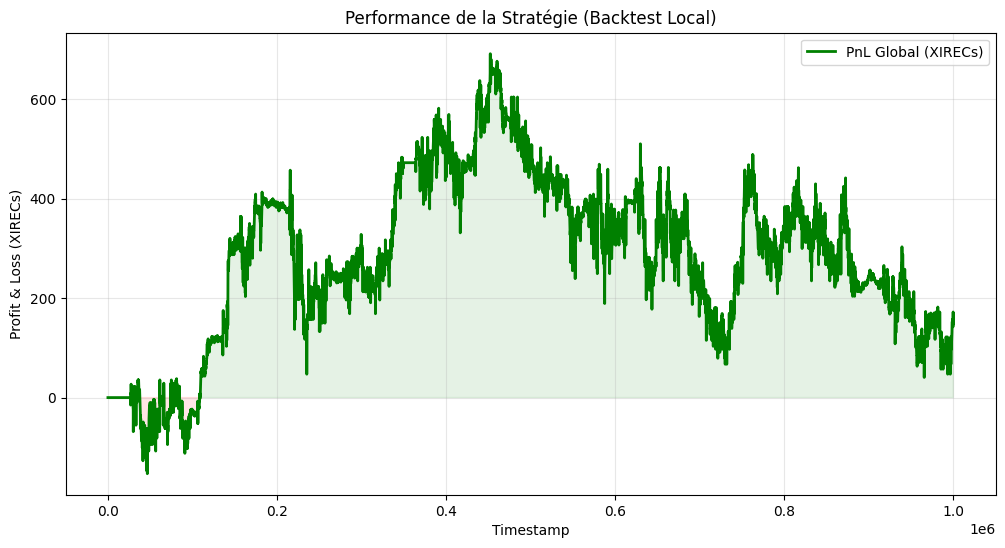

PnL Final : 152.00 XIRECs
Position finale EMERALDS : 0
Position finale TOMATOES : 10


In [54]:
# backtest 

import pandas as pd
import matplotlib.pyplot as plt
from datamodel import OrderDepth, TradingState, Order
import json


def run_custom_backtest(csv_path, trader_class):
    print(f"Début du backtest sur {csv_path}...")
    
    # 1. Chargement et préparation des données
    df = pd.read_csv(csv_path, sep=';')
    df.sort_values(['timestamp', 'product'], inplace=True)
    
    # Remplacer les NaN par 0 pour les volumes
    vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 
                'ask_volume_1', 'ask_volume_2', 'ask_volume_3']
    df[vol_cols] = df[vol_cols].fillna(0)
    
    # Variables d'état globales
    trader = trader_class()
    traderData = ""
    positions = {"EMERALDS": 0, "TOMATOES": 0}
    cash = {"EMERALDS": 0.0, "TOMATOES": 0.0}
    pnl_history = []
    timestamps = []
    
    # Grouper par tick (timestamp)
    grouped = df.groupby('timestamp')
    
    # 2. Boucle de simulation Tick par Tick
    for timestamp, group in grouped:
        order_depths = {}
        mid_prices = {}
        
        # Construire le carnet d'ordres (OrderDepth) pour ce tick
        for _, row in group.iterrows():
            product = row['product']
            depth = OrderDepth()
            
            # Bids (Achats)
            for i in range(1, 4):
                price = row[f'bid_price_{i}']
                vol = row[f'bid_volume_{i}']
                if pd.notna(price) and vol > 0:
                    depth.buy_orders[int(price)] = int(vol)
                    
            # Asks (Ventes) - Rappel : dans Prosperity, les volumes ask sont négatifs
            for i in range(1, 4):
                price = row[f'ask_price_{i}']
                vol = row[f'ask_volume_{i}']
                if pd.notna(price) and vol != 0:
                    depth.sell_orders[int(price)] = int(vol) # Conserve le signe négatif
            
            order_depths[product] = depth
            mid_prices[product] = row['mid_price']
            
        # Créer l'état de trading
        state = TradingState(
            traderData=traderData,
            timestamp=timestamp,
            listings={},
            order_depths=order_depths,
            own_trades={},
            market_trades={},
            position=positions.copy(),
            observations={}
        )
        
        # 3. Appel de VOTRE stratégie
        orders_dict, conversions, traderData = trader.run(state)
        
        # 4. Moteur d'exécution (Matching Engine simplifié)
        for product, orders in orders_dict.items():
            depth = order_depths[product]
            
            for order in orders:
                qty = order.quantity
                
                # ORDRE D'ACHAT (qty > 0)
                if qty > 0:
                    # On trie les asks du moins cher au plus cher
                    asks = sorted(depth.sell_orders.items())
                    for ask_price, ask_vol in asks:
                        if order.price >= ask_price and qty > 0:
                            # Volume disponible (valeur absolue)
                            available_vol = abs(ask_vol)
                            traded = min(qty, available_vol)
                            
                            positions[product] += traded
                            cash[product] -= traded * ask_price
                            qty -= traded
                            
                # ORDRE DE VENTE (qty < 0)
                elif qty < 0:
                    qty_to_sell = abs(qty)
                    # On trie les bids du plus cher au moins cher
                    bids = sorted(depth.buy_orders.items(), reverse=True)
                    for bid_price, bid_vol in bids:
                        if order.price <= bid_price and qty_to_sell > 0:
                            traded = min(qty_to_sell, bid_vol)
                            
                            positions[product] -= traded
                            cash[product] += traded * bid_price
                            qty_to_sell -= traded

        # 5. Calcul du PnL (Mark-to-Market)
        total_pnl = 0
        for prod in positions.keys():
            if prod in mid_prices:
                # PnL = Cash + (Position Actuelle * Prix Actuel)
                prod_pnl = cash[prod] + (positions[prod] * mid_prices[prod])
                total_pnl += prod_pnl
                
        pnl_history.append(total_pnl)
        timestamps.append(timestamp)
        
    # 6. Visualisation des résultats
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, pnl_history, label='PnL Global (XIRECs)', color='green', linewidth=2)
    plt.title("Performance de la Stratégie (Backtest Local)")
    plt.xlabel("Timestamp")
    plt.ylabel("Profit & Loss (XIRECs)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.fill_between(timestamps, pnl_history, 0, where=(pd.Series(pnl_history) >= 0), color='green', alpha=0.1)
    plt.fill_between(timestamps, pnl_history, 0, where=(pd.Series(pnl_history) < 0), color='red', alpha=0.1)
    plt.show()
    
    print(f"PnL Final : {pnl_history[-1]:.2f} XIRECs")
    print(f"Position finale EMERALDS : {positions['EMERALDS']}")
    print(f"Position finale TOMATOES : {positions['TOMATOES']}")
    
    return pnl_history, positions

# --- UTILISATION ---
# Assurez-vous que la classe Trader (celle que nous avons écrite précédemment) est bien exécutée dans une cellule au-dessus.
# Lancement :
pnl, pos = run_custom_backtest("prices_round_0_day_-1.csv", Trader)


Chargement de prices_round_0_day_-1.csv...


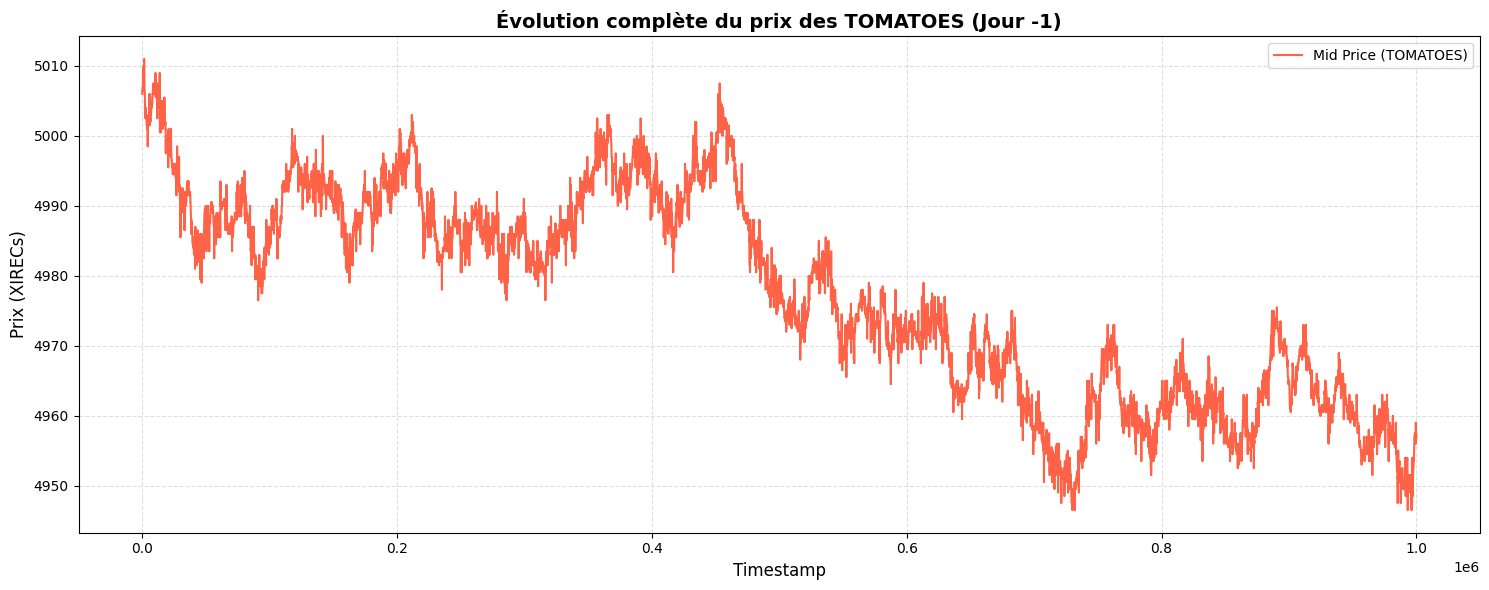

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement des données
csv_path = "prices_round_0_day_-1.csv"
print(f"Chargement de {csv_path}...")
df = pd.read_csv(csv_path, sep=';')

# 2. Filtrage pour isoler les TOMATOES
df_tomatoes = df[df['product'] == 'TOMATOES'].copy()

# 3. Création du graphique
plt.figure(figsize=(15, 6))

# On trace le Mid Price (le prix moyen entre l'achat et la vente)
plt.plot(df_tomatoes['timestamp'], df_tomatoes['mid_price'], 
         color='tomato', linewidth=1.5, label='Mid Price (TOMATOES)')

# 4. Esthétique et lisibilité
plt.title("Évolution complète du prix des TOMATOES (Jour -1)", fontsize=14, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Prix (XIRECs)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()

# Affichage
plt.show()


Chargement de prices_round_0_day_-2.csv...


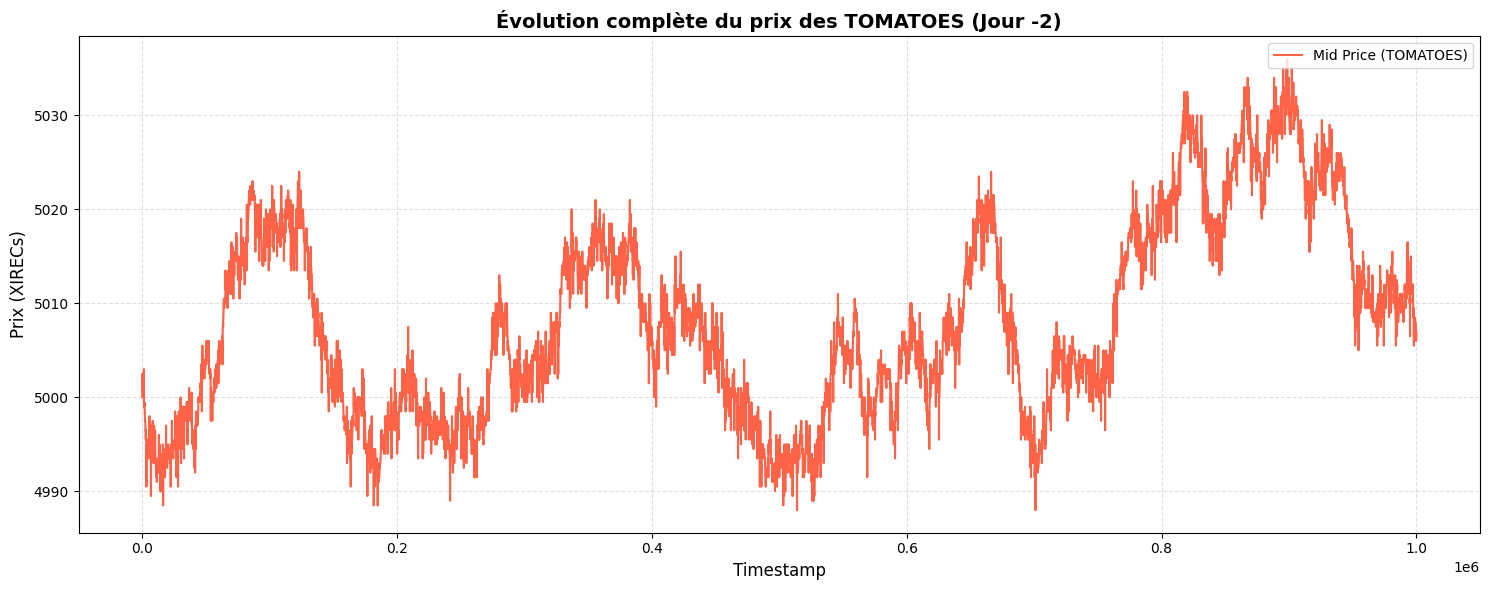

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement des données
csv_path = "prices_round_0_day_-2.csv"
print(f"Chargement de {csv_path}...")
df = pd.read_csv(csv_path, sep=';')

# 2. Filtrage pour isoler les TOMATOES
df_tomatoes = df[df['product'] == 'TOMATOES'].copy()

# 3. Création du graphique
plt.figure(figsize=(15, 6))

# On trace le Mid Price (le prix moyen entre l'achat et la vente)
plt.plot(df_tomatoes['timestamp'], df_tomatoes['mid_price'], 
         color='tomato', linewidth=1.5, label='Mid Price (TOMATOES)')

# 4. Esthétique et lisibilité
plt.title("Évolution complète du prix des TOMATOES (Jour -2)", fontsize=14, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Prix (XIRECs)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()

# Affichage
plt.show()
